# **0. Imbalanced Data & Modeling**


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.data_loader import load_telco, split_features_target
from src.preprocessor import encode_features, add_engineered_features, split_data, get_imbalanced_strategies
from src.evaluate import (
    compute_all_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_pr_curves,
    plot_metrics_comparison, plot_threshold_analysis,
)

IMAGES = "../images"

df = load_telco("../data/Telco-Customer-Churn.csv")
X_raw, y = split_features_target(df)

X_enc = encode_features(X_raw)
X_eng = add_engineered_features(X_enc)

X_model = X_eng.select_dtypes(include=[np.number]).copy()
X_model = X_model.fillna(X_model.median())

print(f"Feature matrix: {X_model.shape}")
print(f"Churn rate: {y.mean():.1%}")

X_train, X_test, y_train, y_test = split_data(X_model, y)

Feature matrix: (7043, 27)
Churn rate: 26.5%


## **1. Why is accuracy ineffective?**

In [2]:
dummy_pred = np.zeros(len(y_test), dtype=int)
dummy_acc  = (dummy_pred == y_test).mean()

print(f"Nếu dự đoán 'No Churn' cho tất cả:")
print(f"  Accuracy : {dummy_acc:.1%}  ← Cao nhưng vô nghĩa")
print(f"  Recall   : 0.0%  ← Không phát hiện được 1 churn nào")
print(f"  F1-Score : 0.0%")
print(f"\n→ PHẢI dùng Precision/Recall/F1/AUC thay vì Accuracy")

Nếu dự đoán 'No Churn' cho tất cả:
  Accuracy : 73.5%  ← Cao nhưng vô nghĩa
  Recall   : 0.0%  ← Không phát hiện được 1 churn nào
  F1-Score : 0.0%

→ PHẢI dùng Precision/Recall/F1/AUC thay vì Accuracy


## **2. Comparing 3 Imbalanced handling strategies**

In [3]:
strategies = get_imbalanced_strategies(X_train, y_train)

strategy_results = {}
for strategy_name, (X_s, y_s) in strategies.items():
    print(f"\n--- {strategy_name} ---")
    print(f"  Train distribution: {y_s.value_counts().to_dict()}")

    if strategy_name == "Original (imbalanced)":
        model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    else:
        model = LogisticRegression(max_iter=1000, random_state=42)

    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_s, y_s)

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    metrics = compute_all_metrics(y_test, y_pred, y_prob)
    strategy_results[strategy_name] = metrics
    print_metrics(metrics, strategy_name)


--- Original (imbalanced) ---
  Train distribution: {0: 4139, 1: 1495}

  Original (imbalanced)
  Accuracy    : 0.740  ██████████████
  Precision   : 0.506  ██████████
  Recall      : 0.797  ███████████████
  F1          : 0.619  ████████████
  AUC-ROC     : 0.848  ████████████████
  PR-AUC      : 0.671  █████████████

--- SMOTE ---
  Train distribution: {0: 4139, 1: 4139}

  SMOTE
  Accuracy    : 0.792  ███████████████
  Precision   : 0.605  ████████████
  Recall      : 0.626  ████████████
  F1          : 0.615  ████████████
  AUC-ROC     : 0.847  ████████████████
  PR-AUC      : 0.676  █████████████

--- Under-sampling ---
  Train distribution: {0: 1495, 1: 1495}

  Under-sampling
  Accuracy    : 0.742  ██████████████
  Precision   : 0.509  ██████████
  Recall      : 0.783  ███████████████
  F1          : 0.617  ████████████
  AUC-ROC     : 0.850  ████████████████
  PR-AUC      : 0.672  █████████████


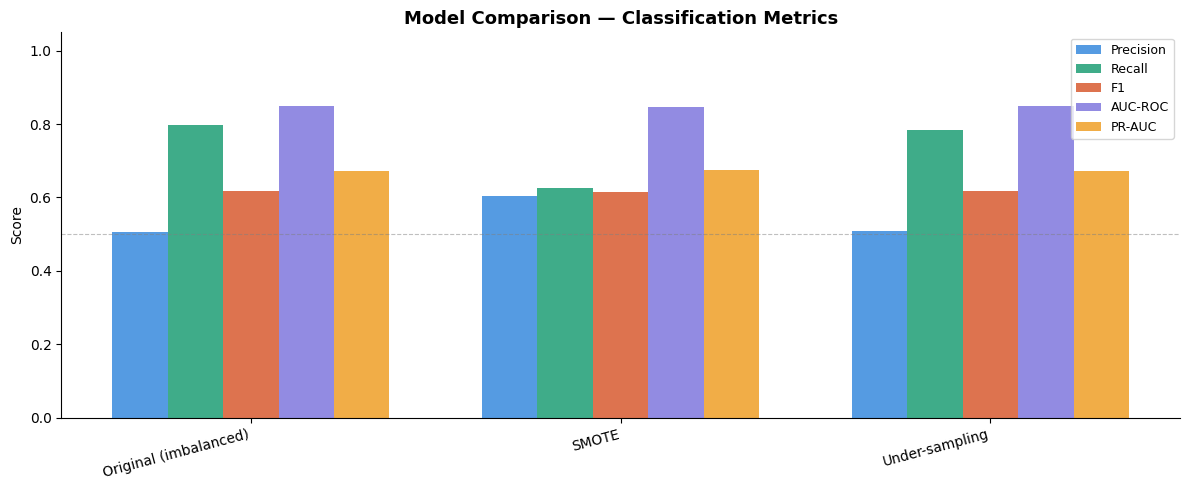


=== Metrics Summary ===
                       Precision  Recall     F1  AUC-ROC  PR-AUC
Original (imbalanced)      0.506   0.797  0.619    0.848   0.671
SMOTE                      0.605   0.626  0.615    0.847   0.676
Under-sampling             0.509   0.783  0.617    0.850   0.672


In [4]:
plot_metrics_comparison(
    strategy_results,
    save_path=f"{IMAGES}/imbalanced_strategy_comparison.png",
)

##  **3.Train  main models**

**Chiến lược:**
- Dùng `class_weight="balanced"` cho tất cả model

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced", C=1.0,
            max_iter=1000, random_state=42
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
    ),
}

from xgboost import XGBClassifier
models["XGBoost"] = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42,
    verbosity=0,
)

In [6]:
all_metrics = {}
all_probs   = {}
fitted_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    metrics = compute_all_metrics(y_test, y_pred, y_prob)
    all_metrics[name] = metrics
    all_probs[name]   = y_prob
    fitted_models[name] = model

    print_metrics(metrics, name)


Training Logistic Regression...

  Logistic Regression
  Accuracy    : 0.740  ██████████████
  Precision   : 0.506  ██████████
  Recall      : 0.797  ███████████████
  F1          : 0.619  ████████████
  AUC-ROC     : 0.848  ████████████████
  PR-AUC      : 0.671  █████████████

Training Random Forest...

  Random Forest
  Accuracy    : 0.774  ███████████████
  Precision   : 0.558  ███████████
  Recall      : 0.709  ██████████████
  F1          : 0.624  ████████████
  AUC-ROC     : 0.841  ████████████████
  PR-AUC      : 0.646  ████████████

Training Gradient Boosting...

  Gradient Boosting
  Accuracy    : 0.798  ███████████████
  Precision   : 0.646  ████████████
  Recall      : 0.532  ██████████
  F1          : 0.584  ███████████
  AUC-ROC     : 0.838  ████████████████
  PR-AUC      : 0.646  ████████████

Training XGBoost...

  XGBoost
  Accuracy    : 0.752  ███████████████
  Precision   : 0.521  ██████████
  Recall      : 0.789  ███████████████
  F1          : 0.628  ████████████


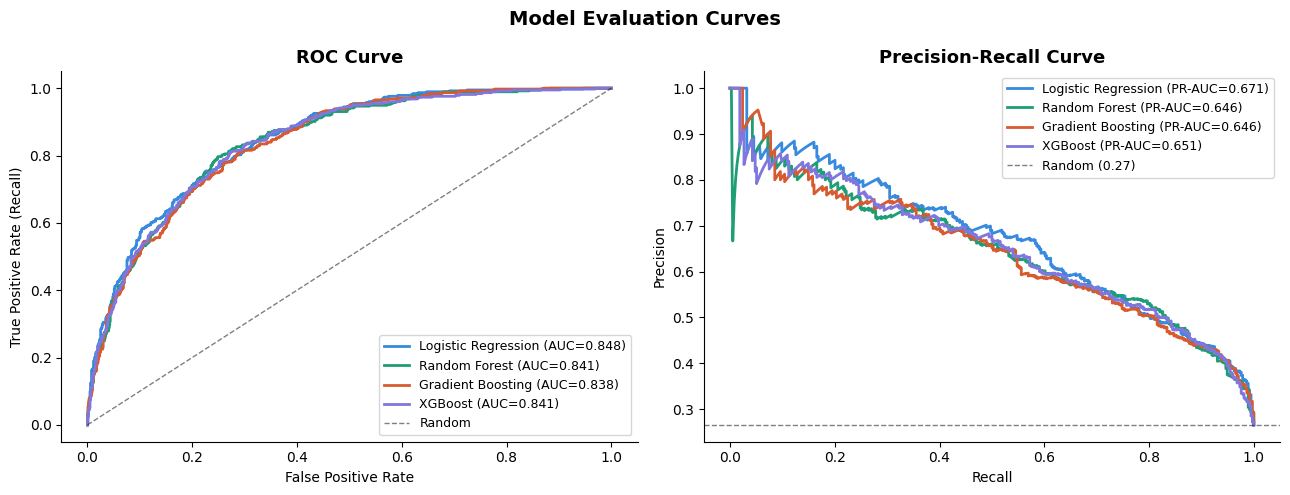

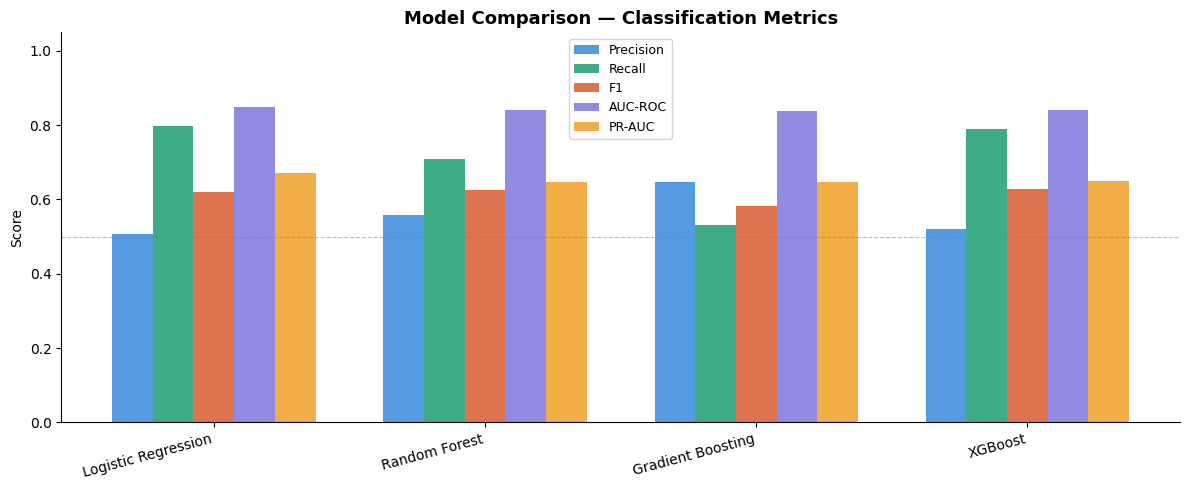


=== Metrics Summary ===
                     Precision  Recall     F1  AUC-ROC  PR-AUC
Logistic Regression      0.506   0.797  0.619    0.848   0.671
Random Forest            0.558   0.709  0.624    0.841   0.646
Gradient Boosting        0.646   0.532  0.584    0.838   0.646
XGBoost                  0.521   0.789  0.628    0.841   0.651


In [7]:
# ROC + PR curves
plot_roc_pr_curves(
    all_probs, y_test,
    save_path=f"{IMAGES}/roc_pr_curves.png",
)

# Model comparison bar chart
plot_metrics_comparison(
    all_metrics,
    save_path=f"{IMAGES}/model_comparison.png",
)

## **4. Select the best model and optimize the threshold**

In [8]:
best_name = max(all_metrics, key=lambda k: all_metrics[k]["AUC-ROC"])
best_model = fitted_models[best_name]
best_prob  = all_probs[best_name]

print(f"Best model: {best_name}")
print(f"AUC-ROC: {all_metrics[best_name]['AUC-ROC']:.3f}")

Best model: Logistic Regression
AUC-ROC: 0.848


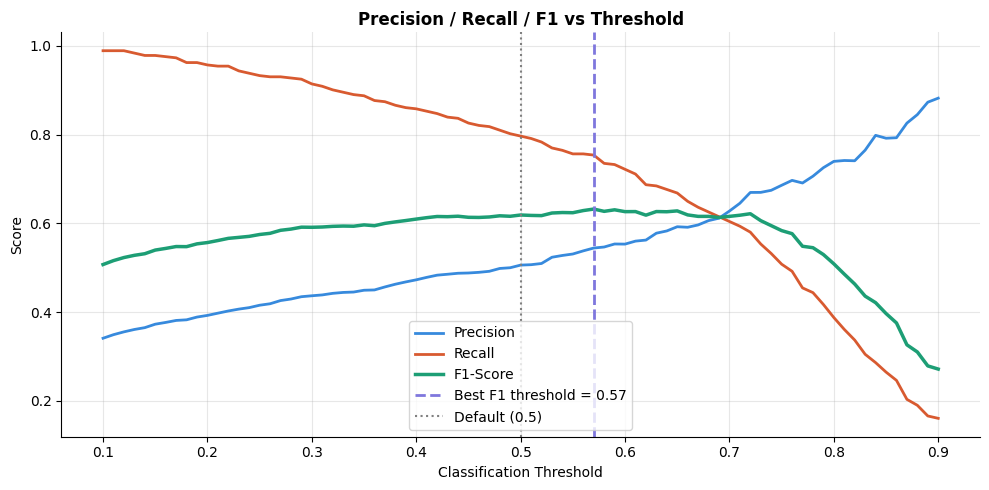


Optimal threshold (F1): 0.57
Default threshold: 0.50


In [9]:
best_threshold = plot_threshold_analysis(
    y_test, best_prob,
    save_path=f"{IMAGES}/threshold_analysis.png",
)
print(f"\nOptimal threshold (F1): {best_threshold:.2f}")
print("Default threshold: 0.50")

In [10]:
y_pred_default  = (best_prob >= 0.50).astype(int)
y_pred_optimal  = (best_prob >= best_threshold).astype(int)

metrics_default = compute_all_metrics(y_test, y_pred_default, best_prob)
metrics_optimal = compute_all_metrics(y_test, y_pred_optimal, best_prob)

print("\n=== Default threshold (0.50) ===")
print_metrics(metrics_default)
print(f"\n=== Optimal threshold ({best_threshold:.2f}) ===")
print_metrics(metrics_optimal)


=== Default threshold (0.50) ===

  Accuracy    : 0.740  ██████████████
  Precision   : 0.506  ██████████
  Recall      : 0.797  ███████████████
  F1          : 0.619  ████████████
  AUC-ROC     : 0.848  ████████████████
  PR-AUC      : 0.671  █████████████

=== Optimal threshold (0.57) ===

  Accuracy    : 0.767  ███████████████
  Precision   : 0.544  ██████████
  Recall      : 0.754  ███████████████
  F1          : 0.632  ████████████
  AUC-ROC     : 0.848  ████████████████
  PR-AUC      : 0.671  █████████████


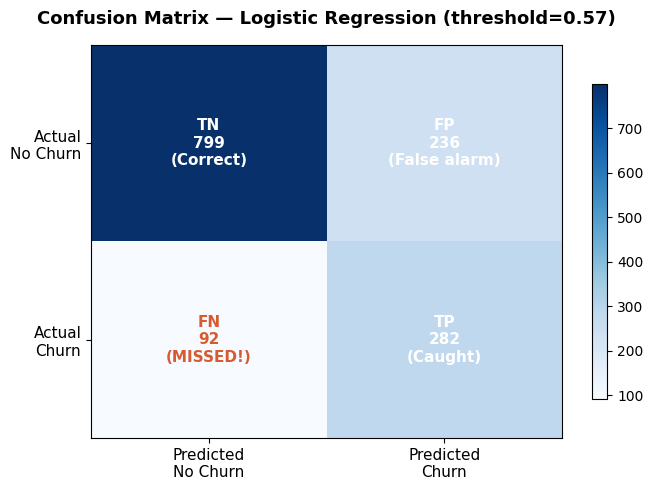


  Recall  = TP/(TP+FN) = 282/374 = 75.4%
  Precision = TP/(TP+FP) = 282/518 = 54.4%
  Khách churn bị bỏ sót (FN): 92


In [11]:
plot_confusion_matrix(
    y_test, y_pred_optimal,
    title=f"Confusion Matrix — {best_name} (threshold={best_threshold:.2f})",
    save_path=f"{IMAGES}/confusion_matrix.png",
)

## **5. Save best model**

In [12]:
import joblib

joblib.dump(best_model,    "../data/best_model.pkl")
joblib.dump(X_model.columns.tolist(), "../data/feature_columns.pkl")

print(f"Saved: best_model.pkl ({best_name})")
print(f"Saved: feature_columns.pkl ({len(X_model.columns)} features)")
print(f"\n======Summary======")
print(f"Best Model  : {best_name}")
print(f"AUC-ROC     : {all_metrics[best_name]['AUC-ROC']:.3f}")
print(f"Recall      : {all_metrics[best_name]['Recall']:.3f}")
print(f"F1          : {all_metrics[best_name]['F1']:.3f}")
print(f"Threshold   : {best_threshold:.2f}")

Saved: best_model.pkl (Logistic Regression)
Saved: feature_columns.pkl (27 features)

======Summary======
Best Model  : Logistic Regression
AUC-ROC     : 0.848
Recall      : 0.797
F1          : 0.619
Threshold   : 0.57
